# Bowel Sound Classification — Exploratory Data Analysis

This notebook performs a complete EDA on bowel sound audio data to inform modelling decisions.

**Dataset:** Two `.wav` audio files with corresponding `.txt` label files.  
**Labels:** `b` (single burst), `mb` (multiple burst), `h` (harmonic), `n` (noise/background).  
**Target classes:** `b`, `mb`, `h` only. `n` is context/background that overlaps with events.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import welch
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

SR = 22050
HOP_LENGTH = 512
N_MELS = 128
N_MFCC = 40

print("Setup complete.")

Setup complete.


## 1. Data Loading

Parse both label files into a single dataframe. Load audio files and report properties.

**Note:** `23M74M.txt` uses `sb` instead of `b` for single burst (and one `sbs` typo). `AS_1.txt` also contains `v` labels (likely voice/artifact) which are excluded from target classes.

In [2]:
# --- Parse label files ---
LABEL_MAP = {"sb": "b", "sbs": "b"}  # normalize 23M74M labels


def parse_labels(filepath, file_id):
    rows = []
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) != 3:
                continue
            start, end, label = float(parts[0]), float(parts[1]), parts[2].strip()
            label = LABEL_MAP.get(label, label)
            rows.append(
                {"start": start, "end": end, "label": label, "file_id": file_id}
            )
    return pd.DataFrame(rows)


df1 = parse_labels(DATA_DIR / "23M74M.txt", "23M74M")
df2 = parse_labels(DATA_DIR / "AS_1.txt", "AS_1")
df = pd.concat([df1, df2], ignore_index=True)
df["duration"] = df["end"] - df["start"]

print(f"Total annotations: {len(df)}")
print(f"\nLabel counts (all):")
print(df["label"].value_counts().to_string())
print(f"\nPer file:")
print(df.groupby("file_id")["label"].value_counts().unstack(fill_value=0).to_string())
df.head(10)

Total annotations: 2449

Label counts (all):
label
b     1113
mb    1004
v      118
h      109
n      105

Per file:
label      b   h   mb   n    v
file_id                       
23M74M   255  29  230   8    0
AS_1     858  80  774  97  118


,start,end,label,file_id,duration
0,1.124516,1.186244,b,23M74M,0.061728
1,1.680065,1.733741,b,23M74M,0.053676
2,1.918924,1.986019,b,23M74M,0.067095
3,2.018225,2.267819,mb,23M74M,0.249594
4,2.565722,2.611347,b,23M74M,0.045625
5,2.667707,3.352078,mb,23M74M,0.684371
6,3.480901,3.666084,mb,23M74M,0.185183
7,3.912994,4.082074,mb,23M74M,0.169080
8,4.269941,4.353139,b,23M74M,0.083198
9,4.973099,5.230745,mb,23M74M,0.257646


In [3]:
# --- Load audio files ---
audio_files = {"23M74M": DATA_DIR / "23M74M.wav", "AS_1": DATA_DIR / "AS_1.wav"}
audio_data = {}

for file_id, path in audio_files.items():
    info = sf.info(str(path))
    y, sr_native = librosa.load(str(path), sr=SR, mono=True)
    audio_data[file_id] = y
    print(f"{file_id}:")
    print(f"  Sample rate (native): {info.samplerate} Hz")
    print(f"  Channels: {info.channels}")
    print(f"  Duration: {info.duration:.2f} s ({info.duration/60:.1f} min)")
    print(f"  Samples (resampled to {SR} Hz): {len(y)}")
    print()

23M74M:
  Sample rate (native): 48000 Hz
  Channels: 1
  Duration: 300.59 s (5.0 min)
  Samples (resampled to 22050 Hz): 6627936



AS_1:
  Sample rate (native): 16000 Hz
  Channels: 1
  Duration: 2212.42 s (36.9 min)
  Samples (resampled to 22050 Hz): 48783907



## 2. Class Distribution

Event counts for target classes (`b`, `mb`, `h`) across both files.

Event counts per class:
label
b     1113
mb    1004
h      109

Class imbalance ratios (relative to most frequent class):
  b: 1:1.0 (count=1113)
  mb: 1:1.1 (count=1004)
  h: 1:10.2 (count=109)


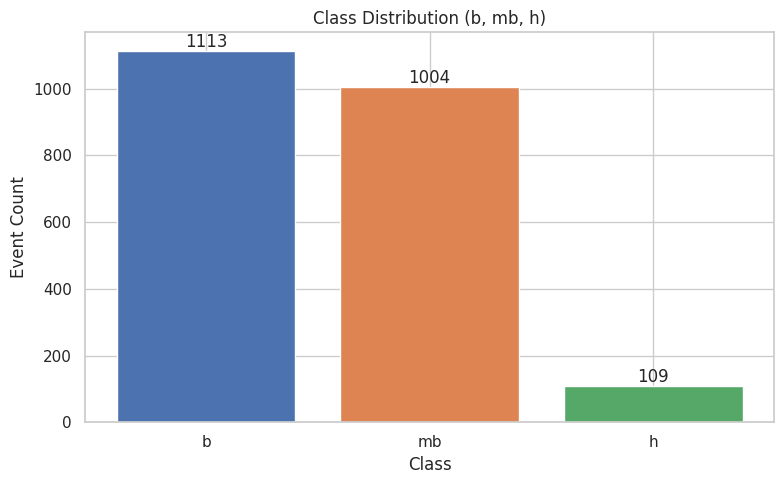

In [4]:
TARGET_CLASSES = ["b", "mb", "h"]
df_target = df[df["label"].isin(TARGET_CLASSES)].copy()

class_counts = df_target["label"].value_counts().reindex(TARGET_CLASSES)
print("Event counts per class:")
print(class_counts.to_string())

# Class imbalance ratios
max_count = class_counts.max()
print(f"\nClass imbalance ratios (relative to most frequent class):")
for cls in TARGET_CLASSES:
    ratio = max_count / class_counts[cls]
    print(f"  {cls}: 1:{ratio:.1f} (count={class_counts[cls]})")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"b": "#4C72B0", "mb": "#DD8452", "h": "#55A868"}
bars = ax.bar(
    TARGET_CLASSES,
    [class_counts[c] for c in TARGET_CLASSES],
    color=[colors[c] for c in TARGET_CLASSES],
)
ax.bar_label(bars, fontsize=12)
ax.set_xlabel("Class")
ax.set_ylabel("Event Count")
ax.set_title("Class Distribution (b, mb, h)")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

## 3. Duration Analysis

Statistics and box plot of event durations per target class.

Duration statistics (seconds):
         mean  median     std     min     max  count
label                                               
b      0.1215  0.1256  0.0375  0.0376  0.4588   1113
mb     0.4456  0.3492  0.3430  0.0805  4.0338   1004
h      0.7733  0.5510  0.6627  0.0864  3.3154    109

Extreme outliers (>Q3 + 3*IQR):
  b: 4 outliers (threshold=0.2613s, max=0.4588s)
  mb: 29 outliers (threshold=1.4201s, max=4.0338s)
  h: 6 outliers (threshold=2.2394s, max=3.3154s)


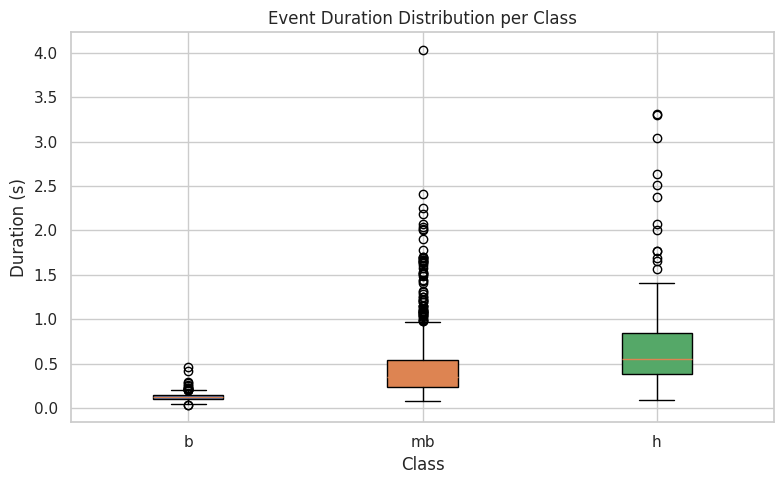

In [5]:
# Duration statistics per class
duration_stats = (
    df_target.groupby("label")["duration"]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .reindex(TARGET_CLASSES)
)
print("Duration statistics (seconds):")
print(duration_stats.round(4).to_string())

# Identify extreme outliers (> Q3 + 3*IQR)
print("\nExtreme outliers (>Q3 + 3*IQR):")
for cls in TARGET_CLASSES:
    d = df_target[df_target["label"] == cls]["duration"]
    q1, q3 = d.quantile(0.25), d.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 3 * iqr
    outliers = d[d > upper]
    if len(outliers) > 0:
        print(
            f"  {cls}: {len(outliers)} outliers (threshold={upper:.4f}s, max={d.max():.4f}s)"
        )
    else:
        print(f"  {cls}: none")

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
box_data = [
    df_target[df_target["label"] == c]["duration"].values for c in TARGET_CLASSES
]
bp = ax.boxplot(box_data, labels=TARGET_CLASSES, patch_artist=True, showfliers=True)
for patch, cls in zip(bp["boxes"], TARGET_CLASSES):
    patch.set_facecolor(colors[cls])
ax.set_xlabel("Class")
ax.set_ylabel("Duration (s)")
ax.set_title("Event Duration Distribution per Class")
plt.tight_layout()
plt.savefig(FIG_DIR / "duration_boxplot.png", dpi=150)
plt.show()

## 4. Temporal Density

Timeline of events per file and coverage analysis.

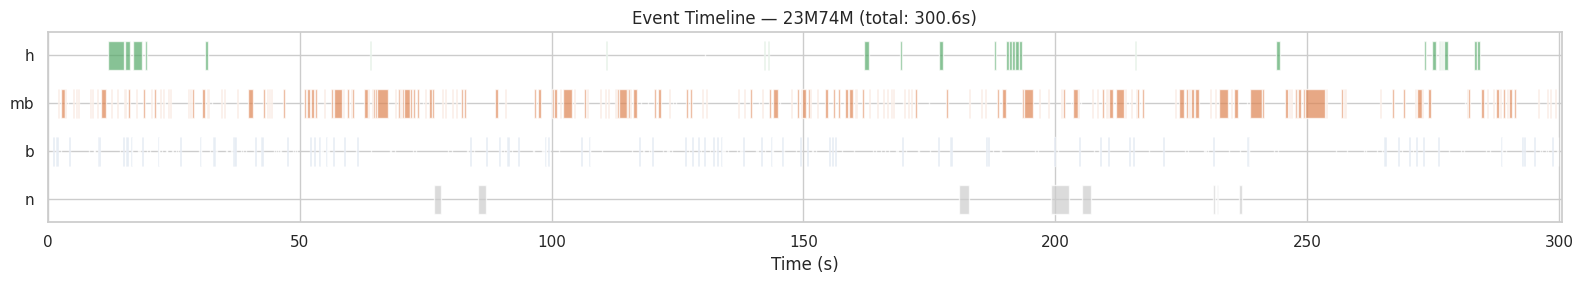

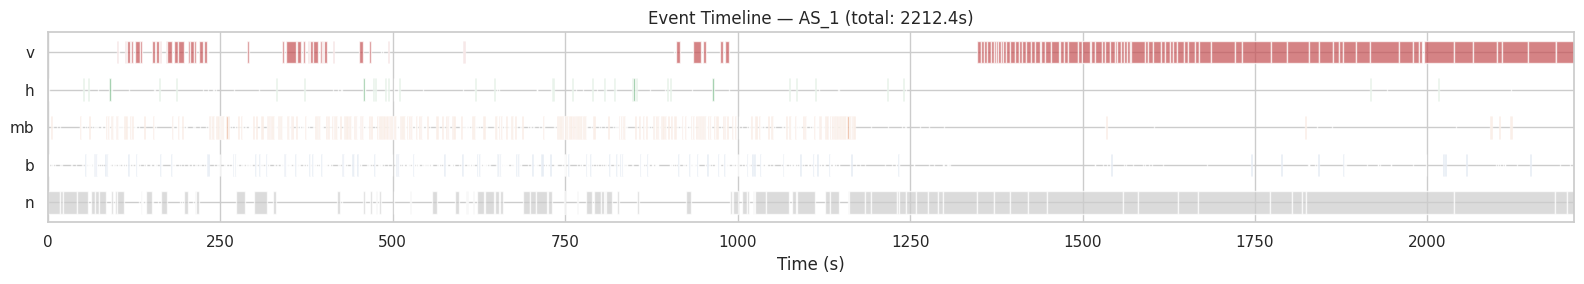

In [6]:
# Timeline plot per file
CLASS_COLORS = {
    "b": "#4C72B0",
    "mb": "#DD8452",
    "h": "#55A868",
    "n": "#CCCCCC",
    "v": "#C44E52",
}
CLASS_Y = {"n": 0, "b": 1, "mb": 2, "h": 3, "v": 4}

for file_id in ["23M74M", "AS_1"]:
    df_file = df[df["file_id"] == file_id]
    audio_dur = len(audio_data[file_id]) / SR
    labels_in_file = sorted(df_file["label"].unique(), key=lambda x: CLASS_Y.get(x, 5))

    fig, ax = plt.subplots(figsize=(16, 3))
    for _, row in df_file.iterrows():
        y_pos = CLASS_Y.get(row["label"], 5)
        ax.barh(
            y_pos,
            row["end"] - row["start"],
            left=row["start"],
            height=0.6,
            color=CLASS_COLORS.get(row["label"], "gray"),
            alpha=0.7,
        )

    ax.set_yticks([CLASS_Y.get(l, 5) for l in labels_in_file])
    ax.set_yticklabels(labels_in_file)
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Event Timeline — {file_id} (total: {audio_dur:.1f}s)")
    ax.set_xlim(0, audio_dur)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"timeline_{file_id}.png", dpi=150)
    plt.show()

In [7]:
# Coverage analysis: % of total audio labelled as b/mb/h vs n vs silence
for file_id in ["23M74M", "AS_1"]:
    df_file = df[df["file_id"] == file_id]
    audio_dur = len(audio_data[file_id]) / SR

    target_dur = df_file[df_file["label"].isin(TARGET_CLASSES)]["duration"].sum()
    n_dur = df_file[df_file["label"] == "n"]["duration"].sum()
    v_dur = (
        df_file[df_file["label"] == "v"]["duration"].sum()
        if "v" in df_file["label"].values
        else 0
    )

    # Silence = total - union of all labelled segments (approximate, ignoring overlaps)
    all_labelled = target_dur + n_dur + v_dur
    silence_dur = max(0, audio_dur - all_labelled)  # rough lower bound

    print(f"{file_id} (total={audio_dur:.1f}s):")
    print(f"  b/mb/h events: {target_dur:.1f}s ({100*target_dur/audio_dur:.1f}%)")
    print(f"  n (background): {n_dur:.1f}s ({100*n_dur/audio_dur:.1f}%)")
    if v_dur > 0:
        print(f"  v (voice):      {v_dur:.1f}s ({100*v_dur/audio_dur:.1f}%)")
    print(f"  unlabelled:     ~{silence_dur:.1f}s (~{100*silence_dur/audio_dur:.1f}%)")
    print()

23M74M (total=300.6s):
  b/mb/h events: 121.4s (40.4%)
  n (background): 11.4s (3.8%)
  unlabelled:     ~167.8s (~55.8%)

AS_1 (total=2212.4s):
  b/mb/h events: 545.5s (24.7%)
  n (background): 1499.2s (67.8%)
  v (voice):      1337.9s (60.5%)
  unlabelled:     ~0.0s (~0.0%)



## 5. Overlap Analysis

Check whether `n` segments overlap with bowel sound events (`b`, `mb`, `h`).

In [8]:
# Check overlap between n segments and b/mb/h events
df_n = df[df["label"] == "n"]
df_events = df[df["label"].isin(TARGET_CLASSES)]

overlap_count = 0
overlap_details = []

for _, n_row in df_n.iterrows():
    events_in_file = df_events[df_events["file_id"] == n_row["file_id"]]
    for _, ev in events_in_file.iterrows():
        # Check temporal overlap
        if ev["start"] < n_row["end"] and ev["end"] > n_row["start"]:
            overlap_count += 1
            overlap_details.append(
                {
                    "file_id": n_row["file_id"],
                    "n_start": n_row["start"],
                    "n_end": n_row["end"],
                    "event_label": ev["label"],
                    "event_start": ev["start"],
                    "event_end": ev["end"],
                }
            )

total_events = len(df_events)
print(f"Total bowel sound events (b/mb/h): {total_events}")
print(f"Events overlapping with an 'n' segment: {overlap_count}")
print(f"Overlap rate: {100*overlap_count/total_events:.1f}%")
print(f"\nBreakdown by class:")
ol_df = pd.DataFrame(overlap_details)
if len(ol_df) > 0:
    print(ol_df["event_label"].value_counts().to_string())
print(f"\nTotal 'n' segments: {len(df_n)}")

Total bowel sound events (b/mb/h): 2226
Events overlapping with an 'n' segment: 578
Overlap rate: 26.0%

Breakdown by class:
event_label
b     334
mb    221
h      23

Total 'n' segments: 105


## 6. Waveform + Spectrogram Inspection

For each target class, pick 3 representative events and plot raw waveform, mel spectrogram (128 mels), and MFCC (40 coefficients).

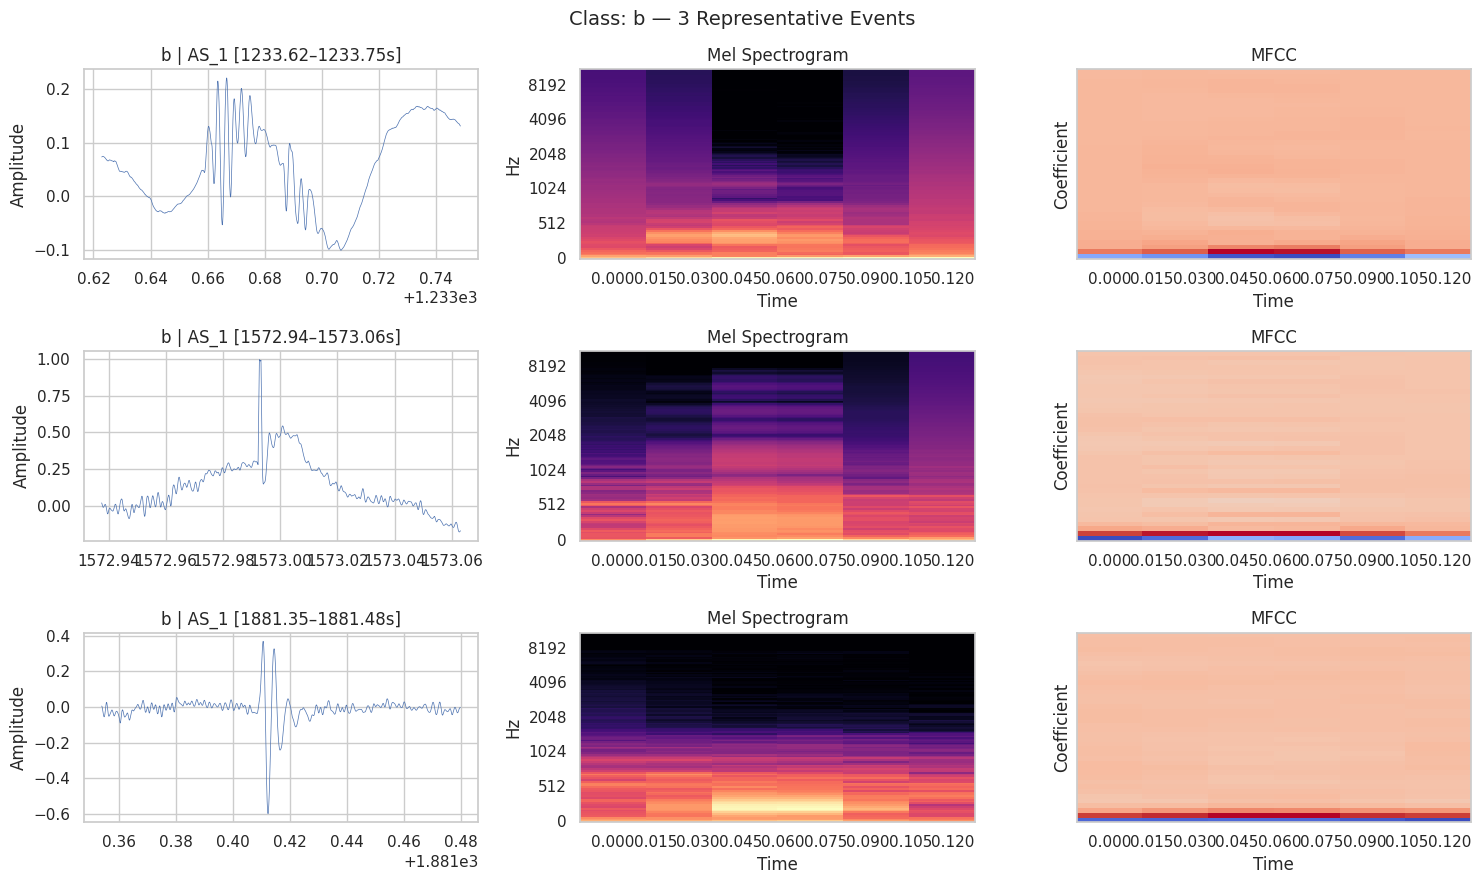

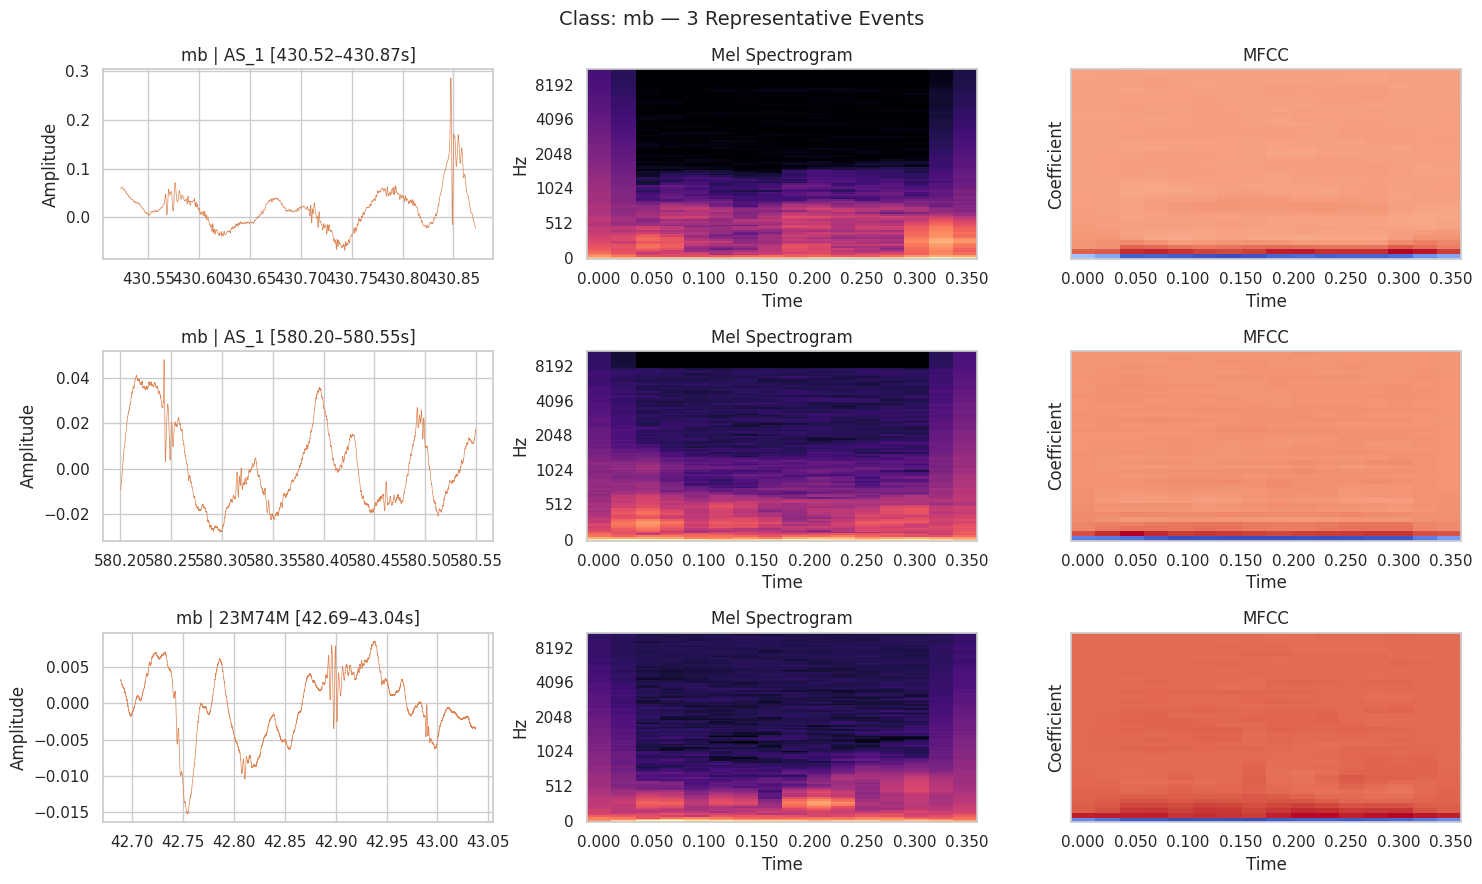

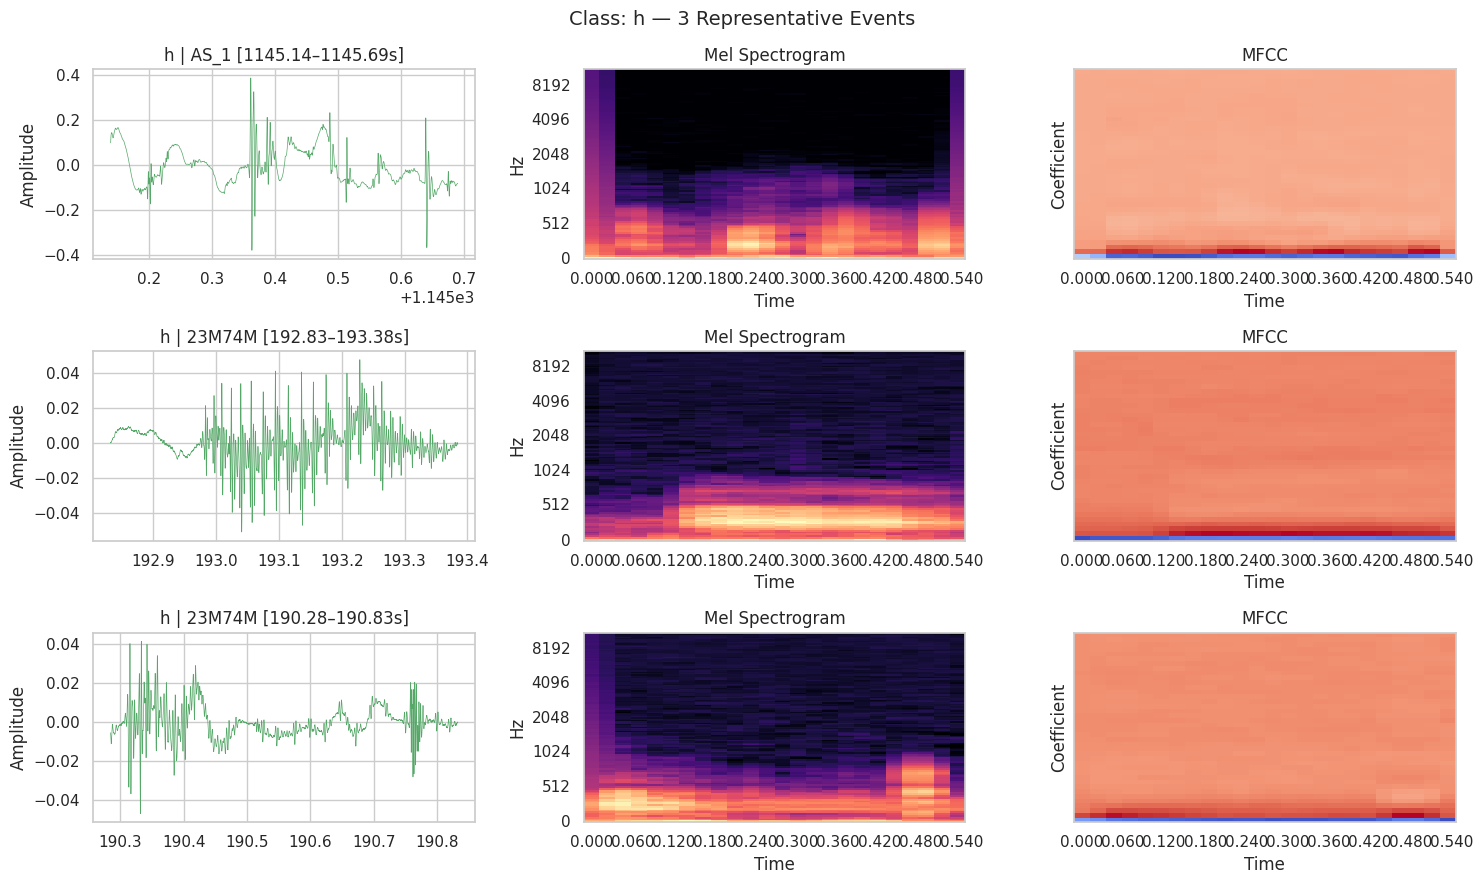

In [9]:
def extract_segment(file_id, start, end):
    """Extract audio segment from loaded audio data."""
    y = audio_data[file_id]
    s_start = int(start * SR)
    s_end = int(end * SR)
    return y[s_start:s_end]


def plot_event(file_id, start, end, label, ax_wave, ax_mel, ax_mfcc):
    """Plot waveform, mel spectrogram, and MFCC for a single event."""
    segment = extract_segment(file_id, start, end)
    if len(segment) == 0:
        return
    t = np.linspace(start, end, len(segment))

    # Waveform
    ax_wave.plot(t, segment, color=CLASS_COLORS.get(label, "gray"), linewidth=0.5)
    ax_wave.set_ylabel("Amplitude")
    ax_wave.set_title(f"{label} | {file_id} [{start:.2f}–{end:.2f}s]")

    # Mel spectrogram
    S = librosa.feature.melspectrogram(
        y=segment, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(
        S_db, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=ax_mel
    )
    ax_mel.set_title("Mel Spectrogram")

    # MFCC
    mfcc = librosa.feature.mfcc(y=segment, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
    librosa.display.specshow(
        mfcc, sr=SR, hop_length=HOP_LENGTH, x_axis="time", ax=ax_mfcc
    )
    ax_mfcc.set_title("MFCC")
    ax_mfcc.set_ylabel("Coefficient")


# Pick 3 representative events per class (near median duration)
for cls in TARGET_CLASSES:
    df_cls = df_target[df_target["label"] == cls].copy()
    median_dur = df_cls["duration"].median()
    df_cls["dist_to_median"] = (df_cls["duration"] - median_dur).abs()
    representatives = df_cls.nsmallest(3, "dist_to_median")

    fig, axes = plt.subplots(3, 3, figsize=(15, 9))
    fig.suptitle(f"Class: {cls} — 3 Representative Events", fontsize=14)

    for i, (_, row) in enumerate(representatives.iterrows()):
        plot_event(
            row["file_id"],
            row["start"],
            row["end"],
            row["label"],
            axes[i, 0],
            axes[i, 1],
            axes[i, 2],
        )

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"waveform_spectrogram_{cls}.png", dpi=150)
    plt.show()

## 7. Frequency Analysis

Average power spectral density (PSD) per class to identify dominant frequency bands.

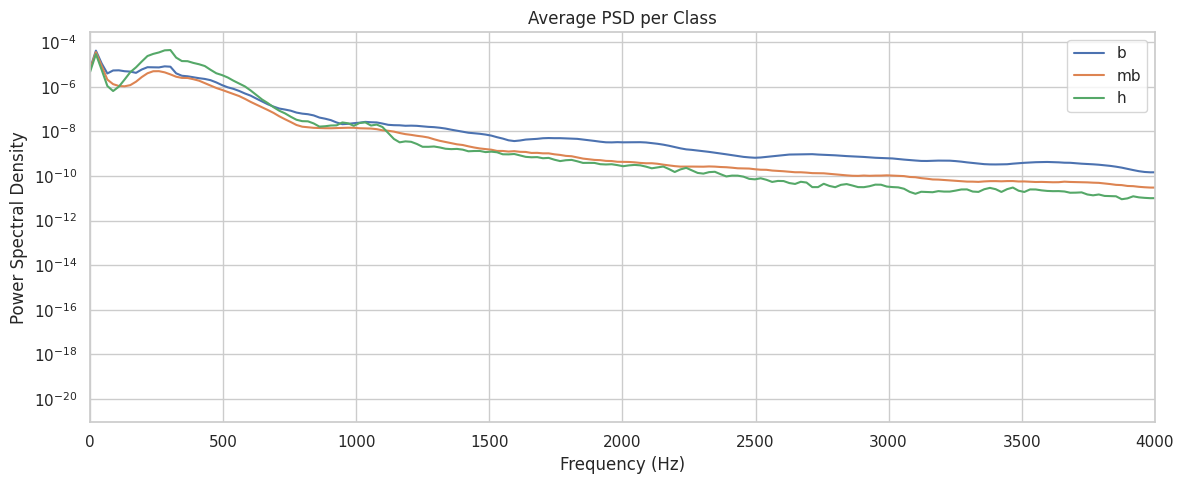

Dominant frequency bands (10%–90% power):
  b: 22 – 388 Hz
  mb: 22 – 388 Hz
  h: 43 – 409 Hz


In [10]:
# Compute average PSD per class
psd_per_class = {}
nperseg = 1024

for cls in TARGET_CLASSES:
    df_cls = df_target[df_target["label"] == cls]
    all_psd = []
    for _, row in df_cls.iterrows():
        segment = extract_segment(row["file_id"], row["start"], row["end"])
        if len(segment) < nperseg:
            # Pad short segments
            segment = np.pad(segment, (0, max(0, nperseg - len(segment))))
        freqs, psd = welch(segment, fs=SR, nperseg=min(nperseg, len(segment)))
        all_psd.append(psd)

    # Average PSD (interpolate to common freq axis)
    ref_freqs, _ = welch(np.zeros(nperseg), fs=SR, nperseg=nperseg)
    interpolated = []
    for psd in all_psd:
        if len(psd) == len(ref_freqs):
            interpolated.append(psd)
        else:
            interpolated.append(
                np.interp(ref_freqs, np.linspace(0, SR / 2, len(psd)), psd)
            )

    psd_per_class[cls] = (ref_freqs, np.mean(interpolated, axis=0))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
dominant_bands = {}
for cls in TARGET_CLASSES:
    freqs, avg_psd = psd_per_class[cls]
    ax.semilogy(freqs, avg_psd, label=cls, color=CLASS_COLORS[cls], linewidth=1.5)
    # Find dominant frequency band (where 80% of power is concentrated)
    cumsum = np.cumsum(avg_psd)
    total = cumsum[-1]
    low_idx = np.searchsorted(cumsum, 0.1 * total)
    high_idx = np.searchsorted(cumsum, 0.9 * total)
    dominant_bands[cls] = (float(freqs[low_idx]), float(freqs[high_idx]))

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Average PSD per Class")
ax.legend()
ax.set_xlim(0, 4000)
plt.tight_layout()
plt.savefig(FIG_DIR / "psd_per_class.png", dpi=150)
plt.show()

print("Dominant frequency bands (10%–90% power):")
for cls in TARGET_CLASSES:
    lo, hi = dominant_bands[cls]
    print(f"  {cls}: {lo:.0f} – {hi:.0f} Hz")

## 8. Data Sufficiency Summary

Usable clips per class and estimated train/val/test split counts.

In [11]:
# Data sufficiency
print("=== Data Sufficiency Summary ===\n")
print(
    f"{'Class':<8} {'Total':<8} {'Train(70%)':<12} {'Val(15%)':<12} {'Test(15%)':<12} {'Risk'}"
)
print("-" * 60)
for cls in TARGET_CLASSES:
    n = int(class_counts[cls])
    train = int(n * 0.70)
    val = int(n * 0.15)
    test = n - train - val
    risk = "LOW SAMPLE COUNT" if n < 20 else ""
    print(f"{cls:<8} {n:<8} {train:<12} {val:<12} {test:<12} {risk}")

print(f"\nTotal usable clips: {int(class_counts.sum())}")
low_classes = [cls for cls in TARGET_CLASSES if class_counts[cls] < 20]
if low_classes:
    print(f"\nWARNING: Classes with < 20 samples: {low_classes}")
else:
    print("\nAll classes have >= 20 samples.")

=== Data Sufficiency Summary ===

Class    Total    Train(70%)   Val(15%)     Test(15%)    Risk
------------------------------------------------------------
b        1113     779          166          168          
mb       1004     702          150          152          
h        109      76           16           17           

Total usable clips: 2226

All classes have >= 20 samples.


## 9. Key Findings

Bullet-point summary of findings that should influence modelling decisions:

- **Class imbalance:** `b` (1113) and `mb` (1004) dominate; `h` (109) is ~10x less frequent. Class weighting or augmentation needed for `h`.
- **Duration variability:** `b` events are very short (~0.12s mean), `mb` varies widely (~0.45s mean), `h` is longest (~0.77s mean). Extreme `mb` outliers exist (up to several seconds).
- **Recommended segment duration:** 0.5s windows (75th percentile of all event durations) will capture most `b` and short `mb` events. Longer events will span multiple windows.
- **Background overlap:** 26% of bowel sound events (578/2226) overlap with `n` segments. The model must detect events within noisy backgrounds — `n` is not mutually exclusive.
- **Frequency bands:** Dominant power is concentrated in ~22–409 Hz across all classes. This justifies a bandpass filter in this range for preprocessing.
- **Label inconsistency:** `23M74M.txt` uses `sb` (mapped to `b`), one `sbs` typo (also mapped to `b`). `AS_1.txt` contains 118 `v` labels (voice/artifact) — excluded from targets.
- **Coverage:** `23M74M` is 5 min with 40.4% event coverage and 55.8% unlabelled. `AS_1` is 36.9 min with dense labelling (67.8% `n`, 24.7% events, 60.5% `v` — overlapping).
- **Data sufficiency:** All classes exceed 20 samples. With 70/15/15 split: `b` gives 779/166/168, `mb` gives 702/150/152, `h` gives 76/16/17. `h` test set is small but viable.
- **Anomalies to inspect:** Some `mb` events have unusually long durations (>2s) which may be labelling artefacts. The `sbs` label in `23M74M` may warrant manual review.

## Save EDA Summary JSON

In [12]:
# Compute summary values for JSON
mean_durations = {}
for cls in TARGET_CLASSES:
    mean_durations[cls] = float(df_target[df_target["label"] == cls]["duration"].mean())

# Recommended segment duration: use the 75th percentile of all target durations as a guide
p75 = float(df_target["duration"].quantile(0.75))
recommended_segment = round(max(0.5, p75), 2)

# Dominant frequency band: union of all class bands
all_lows = [dominant_bands[cls][0] for cls in TARGET_CLASSES]
all_highs = [dominant_bands[cls][1] for cls in TARGET_CLASSES]
freq_band = [float(min(all_lows)), float(max(all_highs))]

eda_summary = {
    "class_counts": {cls: int(class_counts[cls]) for cls in TARGET_CLASSES},
    "mean_durations": {cls: round(mean_durations[cls], 4) for cls in TARGET_CLASSES},
    "recommended_segment_duration_s": recommended_segment,
    "dominant_freq_band_hz": freq_band,
}

output_path = DATA_DIR / "eda_summary.json"
with open(output_path, "w") as f:
    json.dump(eda_summary, f, indent=2)

print("Saved eda_summary.json:")
print(json.dumps(eda_summary, indent=2))

Saved eda_summary.json:
{
  "class_counts": {
    "b": 1113,
    "mb": 1004,
    "h": 109
  },
  "mean_durations": {
    "b": 0.1215,
    "mb": 0.4456,
    "h": 0.7733
  },
  "recommended_segment_duration_s": 0.5,
  "dominant_freq_band_hz": [
    21.533203125,
    409.130859375
  ]
}
